# MiniMax H3 (video + audio) on one CMP 170HX — short-drama shots, four engines, power cap, vs DGX Spark

| Metric (ComfyUI, pruned int8 ConvRot + Turbo LoRA 4-step, 576x1024, 24 fps) | Value |
|---|---:|
| 5.2 s dialogue close-up with native voice, one card, 140 W | **85 s** end to end (≈16x real time) |
| Same shot at a 200 W cap | **59–63 s** (−22 to −30 %) |
| 10.1 s one-take (community prompt), 140 W | 215 s |
| Same 5.2 s shot on one DGX Spark (GB10) | 147–155 s (1.7–1.8x slower) |

![H3 on CMP 170HX: seconds per shot and power cap](../assets/charts/2026-10-06-minimax-h3-video-1card-comfyui.png)

```bash
docker pull pytorch/pytorch@sha256:bfbb4a2b4fdba0fefdb428ea737e626d61bb3daf74a16e1ff935bdb03aa7c3f0
```

Evidence: [`results/2026-10-06-minimax-h3-video-1card-comfyui/`](../results/2026-10-06-minimax-h3-video-1card-comfyui/README.md) · card background: [CMP 170HX understanding](../docs/CMP170HX-UNDERSTANDING.md)

In [1]:
from IPython.display import Video
Video(url="../assets/video/minimax-h3-cmp170hx/p1-kowloon-onetake-turbo4-576x1024.mp4", embed=False, html_attributes="controls loop playsinline")

If the player above does not load: [p1-kowloon-onetake-turbo4-576x1024.mp4](../assets/video/minimax-h3-cmp170hx/p1-kowloon-onetake-turbo4-576x1024.mp4) (10.1 s, H.264 + AAC, native H3 audio, not edited).

![poster frame](../assets/video/minimax-h3-cmp170hx/p1-kowloon-onetake-poster.png)

Generated on one CMP 170HX at 140 W with ComfyUI, Turbo 4-step, seed 10613. Prompt authored by **cocktail peanut** ([@cocktailpeanut](https://x.com/cocktailpeanut/status/2084799914765341083)), used unchanged. Model: MiniMax H3 by **MiniMax** ([MiniMax-AI/MiniMax-H3](https://github.com/MiniMax-AI/MiniMax-H3)), MiniMax H3 Community License; outputs are licensed for the Applicable Territory defined there (worldwide except the EU, the UK, the Republic of Korea and the USA).

In [2]:
# --- Status cell ---
EXPERIMENT = "2026-10-06-minimax-h3-video-1card-comfyui"
RESULTS_DIR = "../results/" + EXPERIMENT
RECEIPTS = RESULTS_DIR + "/receipts"
LIVE = False  # True submits the final ComfyUI request (section 3) to the server in COMFY_URL
ENDPOINT_ENV_VAR = "COMFY_URL"
print("LIVE =", LIVE, "| receipts:", RECEIPTS)

LIVE = False | receipts: ../results/2026-10-06-minimax-h3-video-1card-comfyui/receipts


In [3]:
# --- Helpers: receipts, tables, chart style ---
import json, csv, os, statistics
import pandas as pd, numpy as np
from IPython.display import display, Markdown, Image
import matplotlib
import matplotlib.pyplot as plt

runs = pd.DataFrame(json.load(open(f"{RECEIPTS}/runs.json")))
ok = runs[runs.error.isna()]
warm = ok[~ok.cold & ~ok.tripped]
print(len(runs), "runs in the receipts;", runs.error.notna().sum(), "with an error;", len(warm), "warm, untripped")

def table(df, floatfmt=1):
    display(Markdown(df.round(floatfmt).to_markdown(index=False)))

S = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
matplotlib.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
    "axes.titlesize": 10, "axes.titlecolor": INK, "legend.frameon": False, "lines.linewidth": 2,
})
CFG = {"turbo4": S[0], "turbo8": S[1], "base20": S[2], "base50": S[3]}
CARDC = {"CMP-1": S[0], "CMP-2": S[1], "CMP-3": S[2], "DGX Spark (GB10)": S[3]}
def hbar_labels(ax, bars, fmt="{:.0f} s"):
    for b in bars:
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2, " " + fmt.format(b.get_width()), va="center", color=INK2, fontsize=7)

82 runs in the receipts; 0 with an error; 66 warm, untripped


## 1. TL;DR — what we learned

All statements are **measured** on this run unless labelled otherwise. "Shot" = one generated clip with its own audio track, 576x1024 (9:16), 24 fps.

1. **The production setting on this card is ComfyUI + the pruned int8 ConvRot DiT + the Turbo LoRA at 4 steps.** A 5.2 s dialogue close-up takes 85 s on one card at 140 W, and the scripted line comes out word-exact (Whisper WER 0) in 52 of 57 single-speaker runs; the other 5 add one filler word before the line. 8 steps cost 1.8x; the base model at 20 steps costs 3.9x, at 50 steps 9.3x.
2. **Cost is per DiT step, and a step grows faster than the clip.** About 15.5 s per step for 5.2 s at 576x1024. 3 s → 7.9 s/step, 10 s → 44 s, 15 s → 86 s; 768x1344 → 38.6 s. A 10 s shot costs 2.8x a 5 s shot, so two 5 s shots are about 1.4x cheaper than one 10 s shot. VAE decode adds a near-fixed 15 s per 5 s clip.
3. **At 140 W the card is power-bound.** It draws 134–141 W while sampling, the SM clock falls to about 820–980 MHz, and SageAttention or a different VBIOS does not change the speed.
4. **200 W makes every shot 22–30 % faster at the same energy per clip (≈3.2 Wh).** 250 W reaches −29 to −38 % for one clip from a cool card, but with this host's quiet fan policy a warm card passes 83 °C core in 10–45 s. The limit is core temperature (spec: 85 °C max operating), not HBM (76–84 °C, spec 95 °C). All cards were returned to 140 W.
5. **One DGX Spark (GB10) is about 1.7x slower than one CMP 170HX at 140 W** on the same graph and the public R1 shot: 147 vs 84 s per shot, 27.1 vs 15.8 s per step, and its VAE decode is 2x slower (32 vs 15.6 s).
6. **No other engine beat ComfyUI on this card.** SGLang Diffusion 0.5.21 runs the same int8 files correctly but 2x slower per step, partly because it always conditions on 2,048-px references (1.4x slower at equal conditioning). diffusers with torchao int8 weight-only is 2.5x slower and needs 84 GiB of host RAM to load. SageAttention 1.0.6 gives ±3 %.
7. **Operational traps:** loading both H3 checkpoints (FL2VA + Ref2VA) in one ComfyUI process exceeds 64 GB of VRAM and spills to host RAM until a 40 GiB pod is OOM-killed; run one checkpoint per worker. Two-person scenes keep both scripted lines but insert 4–9 unscripted words in the pause between turns. Whisper reports "thanks for watching" on no-dialogue clips; a VAD pass shows no speech.

In [4]:
pins = {
    "model": "MiniMaxAI/MiniMax-H3 @ 42ed227ee7df40d41602854ae760620d6eb651fe (MiniMax H3 Community License); official checkpoint used by SGLang/diffusers",
    "quantized files (ComfyUI, SGLang)": "Comfy-Org/MiniMax-H3 @ e5eb578a89295337b8ff433a035929ce0279e0b6: minimax_h3_ref2va_pruned_int8_convrot, minimax_h3_fl2va_pruned_int8_convrot, qwen3vl_32b_minimax_h3_int8_convrot, video VAE fp16, audio VAE fp32 (SHA-256 in receipts/env/WEIGHTS.md)",
    "Turbo LoRA": "larryvrh/MiniMax-H3-Turbo-Lora @ 43a74557ac3f6539db8e0f2a959d03feb7a81480: minimax_h3_turbo_v4_step600_ema.safetensors",
    "ComfyUI image": "pytorch/pytorch@sha256:bfbb4a2b4fdba0fefdb428ea737e626d61bb3daf74a16e1ff935bdb03aa7c3f0 (torch 2.11.0+cu130)",
    "ComfyUI + nodes": "comfyanonymous/ComfyUI @ 2f35f4a08176d993cded35dac3332be4f7287f41; Larryvrh/ComfyUI-MiniMax-H3-Turbo @ 4274783a23afcfdbea3b4876cb79effd6c510785; Kosinkadink/ComfyUI-VideoHelperSuite @ 4ee72c065db22c9d96c2427954dc69e7b908444b; Lightricks/ComfyUI-LTXVideo @ 15d09abb5a187a8dcaea2fc31fe51ee96e6c9d0d; venv lock receipts/env/comfyui-venv-pip-freeze.txt (comfy-kitchen 0.2.31)",
    "SGLang image": "lmsysorg/sglang@sha256:b1259f3ea3275f66237c498ea388919729018bc9f01c3d638391e06e2cf3f469 (v0.5.21, torch 2.13.0+cu130) + comfy-kitchen==0.2.31",
    "diffusers": "huggingface/diffusers @ bc5e3bd9c55412cb74b6ac5e4c690fc7030461aa; transformers 5.18.0, torchao 0.18.0, accelerate 1.15.0, torch 2.11.0+cu130",
    "driver": "NVIDIA open 615.71.09 + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 @ 6ca4da72f078553d37089ee741cd128aa7804504; ./install.sh --profile=8gb --no-gen2-service --no-iommu",
    "card tuning": "cachenetics/170tune @ 5eb4775063b6cc055607ee5affecd210b13f0156: CMP-1/CMP-3 (VBIOS 92.00.67.00.01) HBM NDIV 64; CMP-2 (92.00.6D.00.0A) SM VF offset +200 MHz at a 1,410 MHz ceiling",
    "power cap": "nvidia-smi -pl 140 (default for all runs); sweep: -pl 200, -pl 250, back to -pl 140",
    "host": "Proxmox VE 9.2.2, kernel 7.0.2-6-pve; engines in Kubernetes pods (one whole card each) in an LXC sharing the host driver; PCIe Gen2 x16 per card",
    "GB10 reference": "one DGX Spark, ComfyUI on python:3.12-slim-bookworm@sha256:54c85f3c47607a77f32adec749d3c81d1348bf25833671f512b26a9b6d778cb3, same ComfyUI/node commits, driver 580.173.02",
    "QA": "SYSTRAN/faster-whisper 1.2.1, Whisper small.en int8 on CPU, unprompted; jiwer 4.0.0",
}
table(pd.DataFrame(pins.items(), columns=["pin", "value"]))

| pin                               | value                                                                                                                                                                                                                                                                                                                                                                               |
|:----------------------------------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| model                             | MiniMaxAI/MiniMax-H3 @ 42ed227ee7df40d41602854ae760620d6eb651fe (MiniMax H3 Community License); official checkpoint used by SGLang/diffusers                                                                                                                                                                                                                                        |
| quantized files (ComfyUI, SGLang) | Comfy-Org/MiniMax-H3 @ e5eb578a89295337b8ff433a035929ce0279e0b6: minimax_h3_ref2va_pruned_int8_convrot, minimax_h3_fl2va_pruned_int8_convrot, qwen3vl_32b_minimax_h3_int8_convrot, video VAE fp16, audio VAE fp32 (SHA-256 in receipts/env/WEIGHTS.md)                                                                                                                              |
| Turbo LoRA                        | larryvrh/MiniMax-H3-Turbo-Lora @ 43a74557ac3f6539db8e0f2a959d03feb7a81480: minimax_h3_turbo_v4_step600_ema.safetensors                                                                                                                                                                                                                                                              |
| ComfyUI image                     | pytorch/pytorch@sha256:bfbb4a2b4fdba0fefdb428ea737e626d61bb3daf74a16e1ff935bdb03aa7c3f0 (torch 2.11.0+cu130)                                                                                                                                                                                                                                                                        |
| ComfyUI + nodes                   | comfyanonymous/ComfyUI @ 2f35f4a08176d993cded35dac3332be4f7287f41; Larryvrh/ComfyUI-MiniMax-H3-Turbo @ 4274783a23afcfdbea3b4876cb79effd6c510785; Kosinkadink/ComfyUI-VideoHelperSuite @ 4ee72c065db22c9d96c2427954dc69e7b908444b; Lightricks/ComfyUI-LTXVideo @ 15d09abb5a187a8dcaea2fc31fe51ee96e6c9d0d; venv lock receipts/env/comfyui-venv-pip-freeze.txt (comfy-kitchen 0.2.31) |
| SGLang image                      | lmsysorg/sglang@sha256:b1259f3ea3275f66237c498ea388919729018bc9f01c3d638391e06e2cf3f469 (v0.5.21, torch 2.13.0+cu130) + comfy-kitchen==0.2.31                                                                                                                                                                                                                                       |
| diffusers                         | huggingface/diffusers @ bc5e3bd9c55412cb74b6ac5e4c690fc7030461aa; transformers 5.18.0, torchao 0.18.0, accelerate 1.15.0, torch 2.11.0+cu130                                                                                                                                                                                                                                        |
| driver                            | NVIDIA open 615.71.09 + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 @ 6ca4da72f078553d37089ee741cd128aa7804504; ./install.sh --profile=8gb --no-gen2-service --no-iommu                                                                                                                                                                                                     |
| card tuning                       | cachenetics/170tune @ 5eb4775063b6cc055607ee5affecd210b13f0156: CMP-1/CMP-3 (VBIOS 92.00.67.00.01) HBM NDIV 64; CMP-2 (92.00.6D.00.0A) SM VF offset +200 MHz at a 1,410 MHz ceiling                                                                                                                                                                                                 |
| power cap                         | nvidia-smi -pl 140 (default for all runs); sweep: -pl 200, -pl 250, back to -pl 140                                                                                                                                                                                                                                                                                                 |
| host                              | Proxmox VE 9.2.2, kernel 7.0.2-6-pve; engines in Kubernetes pods (one whole card each) in an LXC sharing the host driver; PCIe Gen2 x16 per card                                                                                                                                                                                                                                    |
| GB10 reference                    | one DGX Spark, ComfyUI on python:3.12-slim-bookworm@sha256:54c85f3c47607a77f32adec749d3c81d1348bf25833671f512b26a9b6d778cb3, same ComfyUI/node commits, driver 580.173.02                                                                                                                                                                                                           |
| QA                                | SYSTRAN/faster-whisper 1.2.1, Whisper small.en int8 on CPU, unprompted; jiwer 4.0.0                                                                                                                                                                                                                                                                                                 |

## 2. Results (measured)

### 2.0 Headline chart

Left: one 5.2 s dialogue close-up (T1/R1 geometry: 576x1024, 124 frames, one reference image), warm, by sampler config, on one CMP 170HX at 140 W and at 200 W, and on one DGX Spark. Right: Turbo 4-step shot time vs power cap on two cards with different VBIOS.

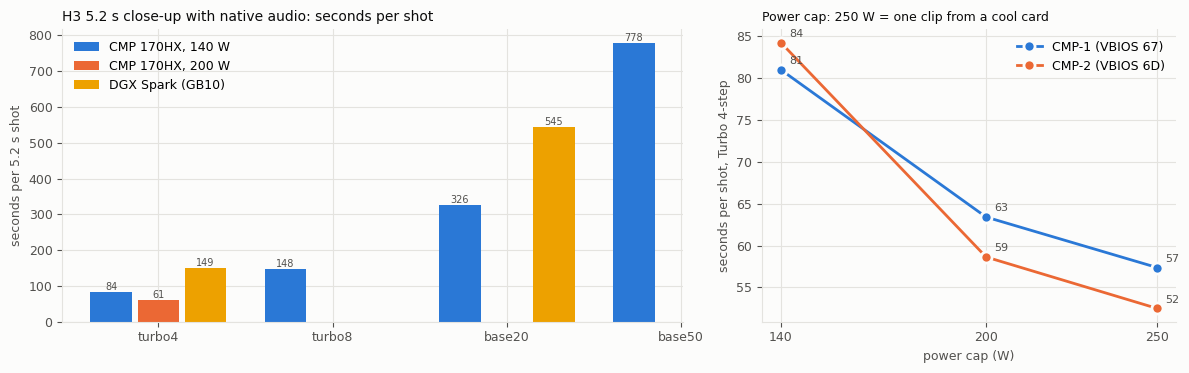

In [5]:
c5 = ok[(ok.engine == "comfyui") & ok.task.isin(["T1_dialogue_closeup", "R1_public_closeup"]) & (ok.frames == 124) & (ok.width == 576)
        & (ok.ref_size == "match") & ~ok.cold & ~ok.tripped]
def grp(d): return d.groupby("config").wall_s.mean()
cmp140 = grp(c5[c5.card.str.startswith("CMP") & (c5.power_cap_w == 140)])
cmp200 = grp(c5[c5.card.str.startswith("CMP") & (c5.power_cap_w == 200)])
gb10 = grp(c5[c5.card.str.startswith("DGX")])
cf = [c for c in ["turbo4", "turbo8", "base20", "base50"] if c in cmp140.index]
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axs[0]; x = np.arange(len(cf)); wd = 0.27
for i, (lab, ser, col) in enumerate([("CMP 170HX, 140 W", cmp140, S[0]), ("CMP 170HX, 200 W", cmp200, S[1]), ("DGX Spark (GB10)", gb10, S[3])]):
    v = [ser.get(c, np.nan) for c in cf]
    b = ax.bar(x + i * wd, v, width=wd - 0.03, color=col, label=lab)
    for bb, vv in zip(b, v):
        if vv == vv: ax.text(bb.get_x() + bb.get_width() / 2, vv, f"{vv:.0f}", ha="center", va="bottom", fontsize=7, color=INK2)
ax.set_xticks(x + wd); ax.set_xticklabels(cf); ax.set_ylabel("seconds per 5.2 s shot"); ax.legend(loc="upper left")
ax.set_title("H3 5.2 s close-up with native audio: seconds per shot", loc="left")
ax = axs[1]
pwr = ok[ok.run_id.str.startswith("pwr-") & (ok.task == "T1_dialogue_closeup") & ~ok.cold & ~ok.tripped]
for c, d in pwr.groupby("card"):
    m = d.groupby("power_cap_w").wall_s.mean()
    ax.plot(m.index, m.values, color=CARDC[c], marker="o", ms=8, mec=SURF, mew=2, label=f"{c} (VBIOS {d.vbios.iloc[0][6:8]})")
    for xx, yy in m.items(): ax.annotate(f"{yy:.0f}", (xx, yy), textcoords="offset points", xytext=(6, 4), fontsize=8, color=INK2)
ax.set_xticks([140, 200, 250]); ax.set_xlabel("power cap (W)"); ax.set_ylabel("seconds per shot, Turbo 4-step"); ax.legend()
ax.set_title("Power cap: 250 W = one clip from a cool card", loc="left", fontsize=9)
plt.tight_layout(); plt.savefig(f"../assets/charts/{EXPERIMENT}.png", dpi=130); plt.show()

### 2.1 Seconds per shot by sampler config

Warm runs (models already in VRAM), mean over seeds. Private tasks used non-public reference images, voices and prompts: their timings are published, their inputs are not. Every step of the same shot costs about the same, so time scales with the step count.

| task                | config   |   runs |   seconds_out |   wall_s |   step_s |   decode_s |    wer |
|:--------------------|:---------|-------:|--------------:|---------:|---------:|-----------:|-------:|
| R1_public_closeup   | base20   |      1 |          5.17 |   322.78 |    15.2  |      15.76 |   0    |
| R1_public_closeup   | turbo4   |      4 |          5.17 |    84.2  |    15.76 |      15.59 |   0.02 |
| T1_dialogue_closeup | base20   |      2 |          5.17 |   327.98 |    15.49 |      15.44 |   0    |
| T1_dialogue_closeup | base50   |      1 |          5.17 |   778.17 |    15.19 |      15.26 |   0    |
| T1_dialogue_closeup | turbo4   |      6 |          5.17 |    83.46 |    15.94 |      15.38 |   0    |
| T1_dialogue_closeup | turbo8   |      1 |          5.17 |   148.19 |    16.22 |      15.49 |   0    |
| T3_voice_ref        | base20   |      1 |          5.17 |   338.98 |    16.02 |      15.44 |   0    |
| T3_voice_ref        | turbo4   |      4 |          5.17 |    89.81 |    16.75 |      15.4  |   0    |
| T3_voice_ref        | turbo8   |      1 |          5.17 |   151.07 |    16.65 |      15.27 |   0    |
| T2_two_person       | base20   |      1 |          7.29 |   623.52 |    29.95 |      21.93 |   0.54 |
| T2_two_person       | turbo4   |      3 |          7.29 |   163.72 |    30.87 |      23.64 |   0.62 |
| T2_two_person       | turbo8   |      1 |          7.29 |   275.42 |    31.33 |      22.2  |   0.46 |
| T4_establishing_i2v | base20   |      1 |          5.17 |   333.83 |    15.73 |      16.04 | nan    |
| T4_establishing_i2v | turbo4   |      1 |          5.17 |    81.38 |    15.67 |      15.65 | nan    |
| T4_establishing_i2v | turbo8   |      1 |          5.17 |   148.58 |    16.23 |      15.81 | nan    |
| T5_t2va_broll       | base20   |      1 |          5.17 |   296.75 |    13.95 |      15.73 | nan    |
| T5_t2va_broll       | turbo4   |      2 |          5.17 |    77.07 |    14.02 |      15.55 | nan    |
| T5_t2va_broll       | turbo8   |      1 |          5.17 |   134.66 |    14.46 |      16.02 | nan    |
| P3_ugc_to_camera    | turbo4   |      1 |          5.17 |    79.78 |    14.15 |      15.63 | nan    |
| P3_ugc_to_camera    | turbo8   |      1 |          5.17 |   132.95 |    14.39 |      15.97 | nan    |
| P1_kowloon_onetake  | turbo8   |      1 |         10.12 |   384.87 |    42.5  |      34.11 | nan    |
| P2_morning_rush     | turbo4   |      1 |         10.12 |   215.47 |    41.49 |      33.39 | nan    |
| P2_morning_rush     | turbo8   |      1 |         10.12 |   377.83 |    42.3  |      31.16 | nan    |

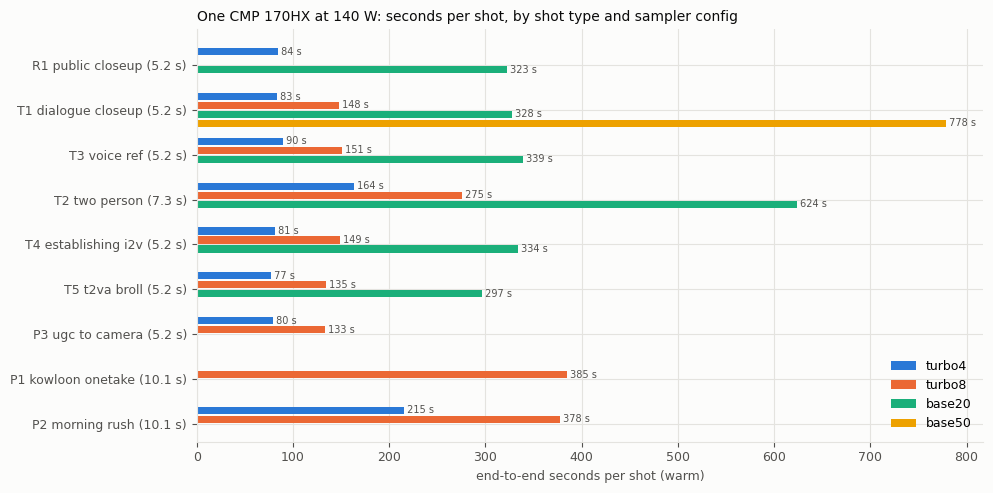

In [6]:
shots = warm[(warm.engine == "comfyui") & warm.card.str.startswith("CMP") & (warm.power_cap_w == 140) & (warm.width == 576)
             & (warm.ref_size != "max") & warm.frames.isin([124, 175, 243])]
order = ["R1_public_closeup", "T1_dialogue_closeup", "T3_voice_ref", "T2_two_person", "T4_establishing_i2v", "T5_t2va_broll",
         "P3_ugc_to_camera", "P1_kowloon_onetake", "P2_morning_rush"]
shots = shots[~((shots.task == "T1_dialogue_closeup") & (shots.frames != 124))]
tab = shots.groupby(["task", "config"]).agg(runs=("run_id", "count"), seconds_out=("out_s", "mean"), wall_s=("wall_s", "mean"),
        step_s=("step_s_mean", "mean"), decode_s=("vae_decode_s", "mean"), wer=("wer", "mean")).reset_index()
tab["task"] = pd.Categorical(tab.task, order); tab = tab.sort_values(["task", "config"])
table(tab, 2)
cfgs = [c for c in CFG if c in set(tab.config)]
tk = [t for t in order if t in set(tab.task)]
fig, ax = plt.subplots(figsize=(10, 5))
w = 0.8 / len(cfgs)
for i, c in enumerate(cfgs):
    v = [tab[(tab.task == t) & (tab.config == c)].wall_s.mean() for t in tk]
    bars = ax.barh(np.arange(len(tk)) + i * w, v, height=w - 0.04, color=CFG[c], label=c)
    hbar_labels(ax, [b for b, x in zip(bars, v) if not np.isnan(x)])
lab = [f"{t.split('_', 1)[0]} {t.split('_', 1)[1].replace('_', ' ')} ({tab[tab.task == t].seconds_out.iloc[0]:.1f} s)" for t in tk]
ax.set_yticks(np.arange(len(tk)) + w * (len(cfgs) - 1) / 2); ax.set_yticklabels(lab); ax.invert_yaxis()
ax.set_xlabel("end-to-end seconds per shot (warm)"); ax.legend(loc="lower right")
ax.set_title("One CMP 170HX at 140 W: seconds per shot, by shot type and sampler config", loc="left")
plt.tight_layout(); plt.savefig(f"../assets/charts/{EXPERIMENT}-shots.png", dpi=130); plt.show()

### 2.2 Where the time goes

5.2 s dialogue close-up (T1 + R1, same geometry). The text encode (Qwen3-VL 32B, int8) costs 8–15 s and ComfyUI caches it when a shot is re-rolled with a new seed, so later takes skip it. The sampler dominates; VAE decode is a fixed ~15 s.

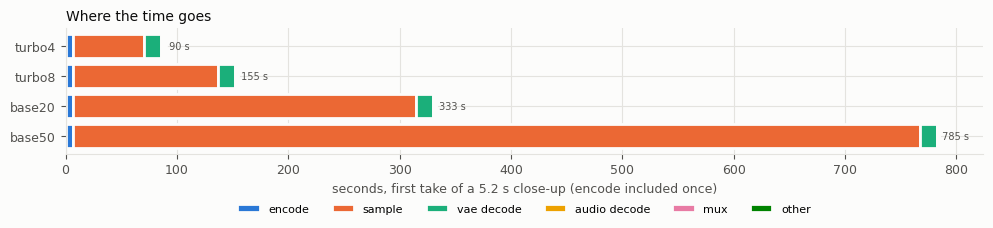

| config   |   encode_s |   sample_s |   vae_decode_s |   audio_decode_s |   mux_s |   other_s |
|:---------|-----------:|-----------:|---------------:|-----------------:|--------:|----------:|
| turbo4   |        6.6 |       63.9 |           15.5 |              0.4 |     2   |         2 |
| turbo8   |        6.6 |      130.2 |           15.5 |              0.4 |     2   |         0 |
| base20   |        6.6 |      308.2 |           15.5 |              0.3 |     2.2 |         0 |
| base50   |        6.6 |      760.4 |           15.3 |              0.5 |     2   |         0 |

In [7]:
t1 = warm[(warm.engine == "comfyui") & warm.card.str.startswith("CMP") & (warm.power_cap_w == 140) & warm.task.isin(["T1_dialogue_closeup", "R1_public_closeup"])
          & (warm.frames == 124) & (warm.width == 576) & (warm.ref_size == "match")]
ph = t1.groupby("config")[["encode_s", "sample_s", "vae_decode_s", "audio_decode_s", "mux_s"]].mean().reindex([c for c in CFG if c in set(t1.config)])
enc = t1[t1.encode_s.notna()].encode_s.mean(); ph["encode_s"] = enc  # first take of a shot pays the encode once
ph["other_s"] = (t1.groupby("config").wall_s.mean().reindex(ph.index) - ph[["sample_s", "vae_decode_s", "audio_decode_s", "mux_s"]].sum(axis=1)).clip(lower=0)
PC = dict(zip(ph.columns, S))
fig, ax = plt.subplots(figsize=(10, 2.6)); left = np.zeros(len(ph))
for c in ph.columns:
    ax.barh(ph.index, ph[c], left=left, color=PC[c], label=c.replace("_s", "").replace("_", " "), edgecolor=SURF, lw=2); left += ph[c].values
for y, x in enumerate(left): ax.text(x, y, f" {x:.0f} s", va="center", color=INK2, fontsize=7)
ax.invert_yaxis(); ax.set_xlabel("seconds, first take of a 5.2 s close-up (encode included once)")
ax.legend(ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.32), fontsize=8)
ax.set_title("Where the time goes", loc="left"); plt.tight_layout(); plt.savefig(f"../assets/charts/{EXPERIMENT}-phases.png", dpi=130); plt.show()
table(ph.reset_index(), 1)

### 2.3 Cost vs clip length and resolution

Turbo 4-step on the T1 geometry (one reference image), 140 W. Step time grows faster than the token count because attention cost grows with the square of the sequence. VRAM stays at 57–58 GB because the weights are resident; activations are small next to them.

|   frames |   seconds_out |   wall_s |   step_s |   decode_s |   peak_vram_gib |   wer |
|---------:|--------------:|---------:|---------:|-----------:|----------------:|------:|
|       73 |          3.04 |    58.49 |     7.86 |       8.8  |           58.23 |   0   |
|      124 |          5.17 |    83.46 |    15.94 |      15.38 |           59.48 |   0   |
|      243 |         10.12 |   234.04 |    44.44 |      33.73 |           56.73 |   0   |
|      362 |         15.08 |   424.67 |    85.78 |      48.69 |           56.67 |   0.1 |

|   width |   height |   megapixels |   wall_s |   step_s |   decode_s |   peak_vram_gib |
|--------:|---------:|-------------:|---------:|---------:|-----------:|----------------:|
|     432 |      768 |         0.33 |    44.65 |     7.11 |       7.97 |           58.29 |
|     576 |     1024 |         0.59 |    83.46 |    15.94 |      15.38 |           59.48 |
|     768 |     1344 |         1.03 |   207.75 |    38.62 |      31.47 |           56.86 |

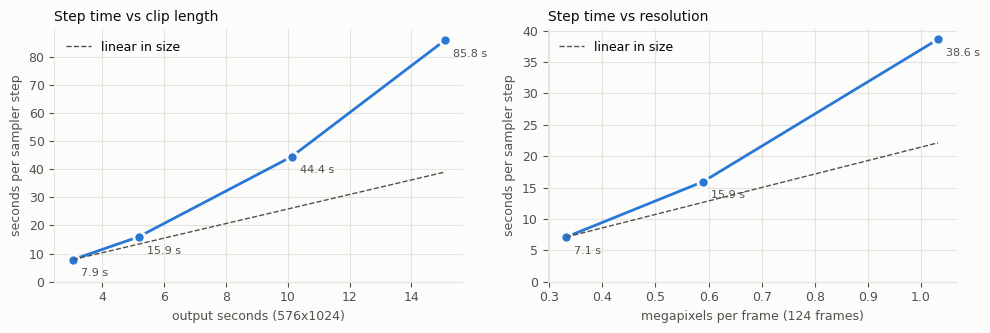

In [8]:
sw = warm[(warm.task == "T1_dialogue_closeup") & (warm.config == "turbo4") & (warm.engine == "comfyui") & warm.card.str.startswith("CMP")
          & (warm.power_cap_w == 140) & (warm.ref_size == "match")]
dur = sw[sw.width == 576].groupby("frames").agg(seconds_out=("out_s", "mean"), wall_s=("wall_s", "mean"), step_s=("step_s_mean", "mean"),
        decode_s=("vae_decode_s", "mean"), peak_vram_gib=("peak_vram_gib", "max"), wer=("wer", "mean")).reset_index()
res = sw[sw.frames == 124].assign(megapixels=lambda d: d.width * d.height / 1e6).groupby(["width", "height"]).agg(megapixels=("megapixels", "first"),
        wall_s=("wall_s", "mean"), step_s=("step_s_mean", "mean"), decode_s=("vae_decode_s", "mean"), peak_vram_gib=("peak_vram_gib", "max")).reset_index()
table(dur, 2); table(res, 2)
fig, axs = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, d, x, xl, ttl in [(axs[0], dur, "seconds_out", "output seconds (576x1024)", "Step time vs clip length"),
                          (axs[1], res, "megapixels", "megapixels per frame (124 frames)", "Step time vs resolution")]:
    ax.plot(d[x], d.step_s, color=S[0], marker="o", ms=8, mec=SURF, mew=2)
    lin = d.step_s.iloc[0] / d[x].iloc[0] * d[x]
    ax.plot(d[x], lin, color=INK2, lw=1, ls="--", label="linear in size")
    for xx, yy in zip(d[x], d.step_s): ax.annotate(f"{yy:.1f} s", (xx, yy), textcoords="offset points", xytext=(6, -12), fontsize=8, color=INK2)
    ax.set_xlabel(xl); ax.set_ylabel("seconds per sampler step"); ax.set_ylim(0); ax.set_title(ttl, loc="left"); ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig(f"../assets/charts/{EXPERIMENT}-scaling.png", dpi=130); plt.show()

### 2.4 Power cap: 140 → 200 → 250 W

The cap was set per card on the host (`nvidia-smi -i <card> -pl <W>`). A host watchdog sampled every 2 s and set a card back to 140 W at 83 °C core or 85 °C HBM. Five runs tripped it; they are listed below and kept out of the sweep table. The two "250 W" sweep points are one clip each from a card at ≤ 50 °C.

In [9]:
pw = ok[ok.run_id.str.startswith("pwr-") | ok.run_id.str.startswith("comm-")].copy()
temps = pd.read_csv(f"{RECEIPTS}/power-sweep/telemetry.csv")
import datetime as dt
temps["t"] = [dt.datetime.strptime("2026-10-06 " + x, "%Y-%m-%d %H:%M:%S").replace(tzinfo=dt.timezone.utc).timestamp() for x in temps["time_utc_2026-10-06"]]
def peak(r, col):
    w = temps[(temps.card == r.card) & (temps.t >= r.t_submit) & (temps.t <= r.t_done)]
    return w[col].max() if len(w) else np.nan
pw["max_core_c"] = [peak(r, "core_c") for r in pw.itertuples()]
pw["max_hbm_c"] = [peak(r, "hbm_c") for r in pw.itertuples()]
sweep = pw[(pw.task == "T1_dialogue_closeup") & ~pw.tripped & ~pw.cold].groupby(["card", "vbios", "power_cap_w"]).agg(runs=("run_id", "count"),
        wall_s=("wall_s", "mean"), step_s=("step_s_mean", "mean"), power_w=("mean_power_w", "mean"), sm_mhz=("mean_sm_mhz", "mean"),
        energy_wh=("energy_wh", "mean"), max_core_c=("max_core_c", "max"), max_hbm_c=("max_hbm_c", "max"), wer=("wer", "mean")).reset_index()
sweep["faster_vs_140"] = sweep.groupby("card").step_s.transform(lambda s: 1 - s / s.iloc[0])
table(sweep, 2)
display(Markdown("**Runs the watchdog pulled back to 140 W** (requested cap shown)"))
table(pw[pw.tripped][["run_id", "card", "power_cap_w", "wall_s", "step_s_mean", "max_core_c", "max_hbm_c", "note"]], 1)
p1 = pw[(pw.task == "P1_kowloon_onetake") & (pw.config == "turbo4")][["run_id", "card", "power_cap_w", "cold", "tripped", "wall_s", "step_s_mean", "mean_power_w", "max_core_c", "max_hbm_c"]]
display(Markdown("**P1 10.1 s one-take, Turbo 4-step** (the 140 W run is the first job after a worker restart: its first step includes model load)")); table(p1, 1)

| card   | vbios          |   power_cap_w |   runs |   wall_s |   step_s |   power_w |   sm_mhz |   energy_wh |   max_core_c |   max_hbm_c |   wer |   faster_vs_140 |
|:-------|:---------------|--------------:|-------:|---------:|---------:|----------:|---------:|------------:|-------------:|------------:|------:|----------------:|
| CMP-1  | 92.00.67.00.01 |           140 |      2 |    80.98 |    15.75 |    136.02 |   858.69 |        3.03 |           70 |          71 |  0    |            0    |
| CMP-1  | 92.00.67.00.01 |           200 |      2 |    63.4  |    12.21 |    189.6  |  1144.69 |        3.27 |           79 |          77 |  0.05 |            0.23 |
| CMP-1  | 92.00.67.00.01 |           250 |      1 |    57.37 |    10.91 |    235.4  |  1292.39 |        3.56 |           76 |          70 |  0    |            0.31 |
| CMP-2  | 92.00.6D.00.0A |           140 |      1 |    84.22 |    16.24 |    137.51 |   817.95 |        3.13 |           67 |          70 |  0    |            0    |
| CMP-2  | 92.00.6D.00.0A |           200 |      2 |    58.63 |    11.2  |    194.63 |  1223.08 |        3.07 |           81 |          79 |  0    |            0.31 |
| CMP-2  | 92.00.6D.00.0A |           250 |      1 |    52.49 |     9.97 |    227.32 |  1392.41 |        3.27 |           80 |          76 |  0.1  |            0.39 |

**Runs the watchdog pulled back to 140 W** (requested cap shown)

| run_id                          | card   |   power_cap_w |   wall_s |   step_s_mean |   max_core_c |   max_hbm_c | note                                                                                                      |
|:--------------------------------|:-------|--------------:|---------:|--------------:|-------------:|------------:|:----------------------------------------------------------------------------------------------------------|
| pwr-cmp3-P1-turbo4-pl250-s10620 | CMP-3  |           250 |    183.2 |          40   |           84 |          84 | watchdog tripped CMP-3 to 140 W at 16:37:18 UTC, 44 s into this run (core 84 C, HBM 81 C)                 |
| pwr-cmp1-T1-turbo4-pl250-s10605 | CMP-1  |           250 |     76.1 |          15.5 |           83 |          78 | watchdog tripped CMP-1 to 140 W at 16:13:01 UTC, about 20 s into this run (core 83 C)                     |
| pwr-cmp1-T1-turbo4-pl250-s10606 | CMP-1  |           250 |     82.5 |          16   |           70 |          71 | ran at 140 W: watchdog had already tripped CMP-1 at 16:13:01 UTC                                          |
| pwr-cmp2-T1-turbo4-pl250-s10611 | CMP-2  |           250 |     84.9 |          17.5 |           83 |          79 | watchdog tripped CMP-2 to 140 W at 16:15:12 UTC, 9 s after the cap was set (card hot from the 200 W runs) |
| pwr-cmp2-T1-turbo4-pl250-s10612 | CMP-2  |           250 |     87.7 |          17.2 |           74 |          76 | ran at 140 W after the 16:15:12 UTC trip                                                                  |

**P1 10.1 s one-take, Turbo 4-step** (the 140 W run is the first job after a worker restart: its first step includes model load)

| run_id                           | card   |   power_cap_w | cold   | tripped   |   wall_s |   step_s_mean |   mean_power_w |   max_core_c |   max_hbm_c |
|:---------------------------------|:-------|--------------:|:-------|:----------|---------:|--------------:|---------------:|-------------:|------------:|
| comm-cmp3-P1-turbo4-pl140-s10613 | CMP-3  |           140 | True   | False     |    351   |          40.7 |          114.1 |           63 |          69 |
| pwr-cmp3-P1-turbo4-pl200-s10619  | CMP-3  |           200 | False  | False     |    152   |          31.2 |          194   |           80 |          82 |
| pwr-cmp3-P1-turbo4-pl250-s10620  | CMP-3  |           250 | False  | True      |    183.2 |          40   |          169.8 |           84 |          84 |

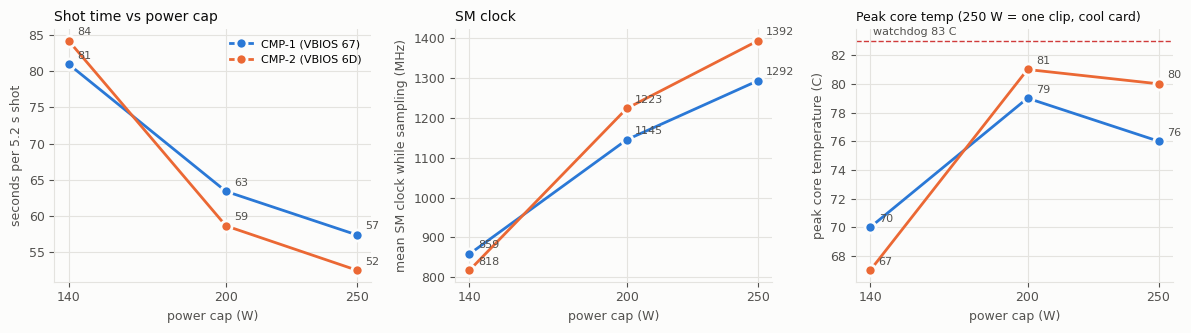

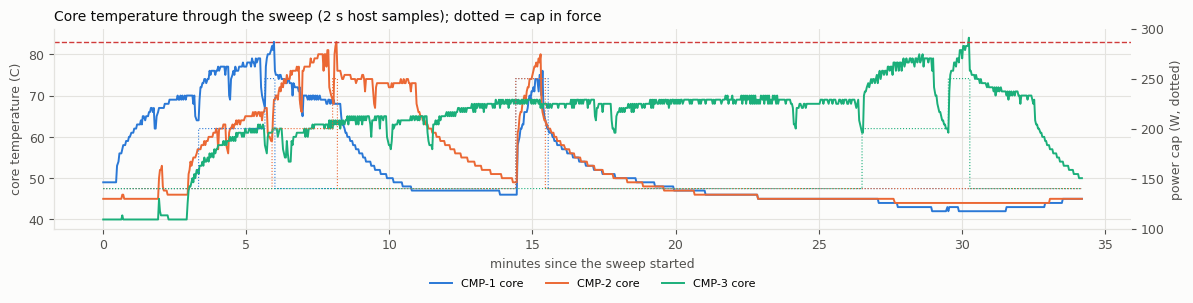

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.4))
for k, (c, d) in enumerate(sweep.groupby("card")):
    lab = f"{c} (VBIOS {d.vbios.iloc[0][6:8]})"
    for ax, col, yl in [(axs[0], "wall_s", "seconds per 5.2 s shot"), (axs[1], "mean_sm", "mean SM clock while sampling (MHz)"), (axs[2], "max_core_c", "peak core temperature (C)")]:
        y = d.sm_mhz if col == "mean_sm" else d[col]
        ax.plot(d.power_cap_w, y, color=CARDC[c], marker="o", ms=8, mec=SURF, mew=2, label=lab)
        for xx, yy in zip(d.power_cap_w, y): ax.annotate(f"{yy:.0f}", (xx, yy), textcoords="offset points", xytext=(6, 4), fontsize=8, color=INK2)
        ax.set_xticks([140, 200, 250]); ax.set_xlabel("power cap (W)"); ax.set_ylabel(yl)
axs[2].axhline(83, color="#d03b3b", lw=1, ls="--"); axs[2].text(141, 83.4, "watchdog 83 C", fontsize=8, color=INK2)
axs[0].set_title("Shot time vs power cap", loc="left"); axs[1].set_title("SM clock", loc="left"); axs[2].set_title("Peak core temp (250 W = one clip, cool card)", loc="left", fontsize=9)
axs[0].legend(fontsize=8); plt.tight_layout(); plt.savefig(f"../assets/charts/{EXPERIMENT}-power.png", dpi=130); plt.show()
# temperature trace through the sweep: what a warm card does at each cap
fig, ax = plt.subplots(figsize=(12, 3.2))
for c in ["CMP-1", "CMP-2", "CMP-3"]:
    d = temps[temps.card == c]; t0 = temps.t.min()
    ax.plot((d.t - t0) / 60, d.core_c, color=CARDC[c], lw=1.4, label=f"{c} core")
ax2 = ax.twinx(); ax2.grid(False)
for c in ["CMP-1", "CMP-2", "CMP-3"]:
    d = temps[temps.card == c]; ax2.step((d.t - temps.t.min()) / 60, d.power_limit_w, color=CARDC[c], lw=0.8, ls=":", where="post")
ax2.set_ylabel("power cap (W, dotted)"); ax2.set_ylim(100, 300)
ax.axhline(83, color="#d03b3b", lw=1, ls="--"); ax.set_xlabel("minutes since the sweep started"); ax.set_ylabel("core temperature (C)")
ax.set_title("Core temperature through the sweep (2 s host samples); dotted = cap in force", loc="left")
ax.legend(loc="upper center", ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.2))
plt.tight_layout(); plt.savefig(f"../assets/charts/{EXPERIMENT}-temps.png", dpi=130); plt.show()

### 2.5 CMP 170HX vs DGX Spark (GB10)

Same ComfyUI graphs, same weights. R1 is the public version of the 5.2 s close-up (inputs in `receipts/inputs/`); T1 is the private shot with the same geometry.

| task                | config   | machine           |   runs |   wall_s |   step_s |   encode_s |   decode_s |   wer |
|:--------------------|:---------|:------------------|-------:|---------:|---------:|-----------:|-----------:|------:|
| R1_public_closeup   | base20   | CMP 170HX (140 W) |      1 |   322.78 |    15.2  |     nan    |      15.76 |  0    |
| R1_public_closeup   | base20   | DGX Spark (GB10)  |      1 |   533.99 |    25.04 |     nan    |      32.11 |  0    |
| R1_public_closeup   | turbo4   | CMP 170HX (140 W) |      4 |    84.2  |    15.76 |       6.03 |      15.59 |  0.02 |
| R1_public_closeup   | turbo4   | DGX Spark (GB10)  |      2 |   146.68 |    27.08 |       5.36 |      32.29 |  0    |
| T1_dialogue_closeup | base20   | CMP 170HX (140 W) |      2 |   327.98 |    15.49 |     nan    |      15.44 |  0    |
| T1_dialogue_closeup | base20   | DGX Spark (GB10)  |      1 |   556.71 |    25.54 |      12.41 |      32.15 |  0    |
| T1_dialogue_closeup | base50   | CMP 170HX (140 W) |      1 |   778.17 |    15.19 |     nan    |      15.26 |  0    |
| T1_dialogue_closeup | turbo4   | CMP 170HX (140 W) |      6 |    83.46 |    15.94 |       7.88 |      15.38 |  0    |
| T1_dialogue_closeup | turbo4   | DGX Spark (GB10)  |      1 |   154.7  |    27.3  |      12.35 |      32.26 |  0    |
| T1_dialogue_closeup | turbo8   | CMP 170HX (140 W) |      1 |   148.19 |    16.22 |     nan    |      15.49 |  0    |

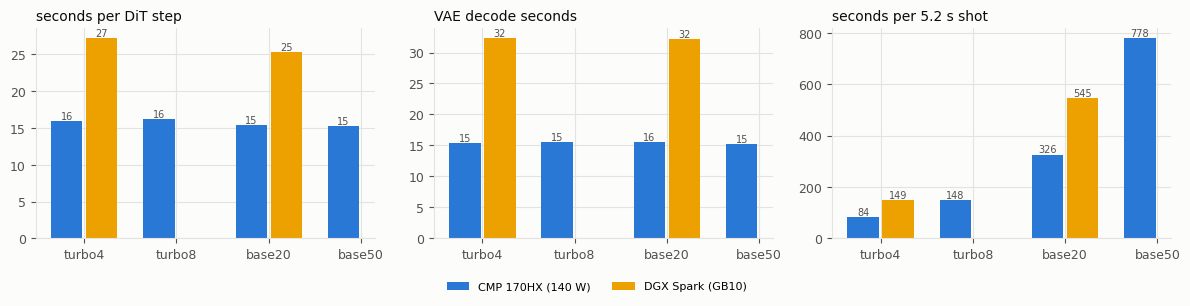

In [11]:
hw = warm[(warm.engine == "comfyui") & warm.task.isin(["R1_public_closeup", "T1_dialogue_closeup"]) & (warm.frames == 124)
          & (warm.width == 576) & (warm.ref_size == "match") & ((warm.power_cap_w == 140) | warm.power_cap_w.isna())]
hw = hw.assign(machine=np.where(hw.card.str.startswith("CMP"), "CMP 170HX (140 W)", "DGX Spark (GB10)"))
cmp_t = hw.groupby(["task", "config", "machine"]).agg(runs=("run_id", "count"), wall_s=("wall_s", "mean"), step_s=("step_s_mean", "mean"),
        encode_s=("encode_s", "mean"), decode_s=("vae_decode_s", "mean"), wer=("wer", "mean")).reset_index()
table(cmp_t, 2)
g = hw.groupby(["machine", "config"]).agg(step_s=("step_s_mean", "mean"), decode_s=("vae_decode_s", "mean"), wall_s=("wall_s", "mean")).reset_index()
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
for ax, col, ttl in [(axs[0], "step_s", "seconds per DiT step"), (axs[1], "decode_s", "VAE decode seconds"), (axs[2], "wall_s", "seconds per 5.2 s shot")]:
    d = g.pivot(index="config", columns="machine", values=col).reindex([c for c in CFG if c in set(g.config)])
    x = np.arange(len(d)); wd = 0.38
    for i, m in enumerate(d.columns):
        b = ax.bar(x + i * wd, d[m], width=wd - 0.04, color=[S[0], S[3]][i], label=m)
        for bb in b: ax.text(bb.get_x() + bb.get_width() / 2, bb.get_height(), f"{bb.get_height():.0f}", ha="center", va="bottom", fontsize=7, color=INK2)
    ax.set_xticks(x + wd / 2); ax.set_xticklabels(d.index); ax.set_title(ttl, loc="left")
fig.legend(*axs[0].get_legend_handles_labels(), loc="lower center", ncol=2, fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=(0, 0.07, 1, 1)); plt.savefig(f"../assets/charts/{EXPERIMENT}-gb10.png", dpi=130); plt.show()

### 2.6 Inference engines on the same card

5.2 s close-up, 140 W, one whole card each. `ref match` = references scaled to the output area (the ComfyUI node default used in this lane); `ref 2048` = references at a 2,048-px short edge (what SGLang and the diffusers reference pipeline always do). SGLang and diffusers ran the private T1/T3 inputs only; their outputs passed the same ASR check (WER 0).

| label                                      |   runs |   step_s |   wall_warm_s |   load_s |   peak_vram_gib |   wer |
|:-------------------------------------------|-------:|---------:|--------------:|---------:|----------------:|------:|
| comfyui | ref match | base50               |      1 |    15.19 |        778.17 |     0    |           55.98 |  0    |
| comfyui-sageattention | ref match | base20 |      1 |    15.23 |        323.19 |     0    |           54.98 |  0    |
| comfyui | ref match | base20               |      4 |    15.55 |        329.43 |     0    |           55.92 |  0    |
| comfyui | ref match | turbo4               |     18 |    16.05 |         85.48 |    13.35 |           60.2  |  0.01 |
| comfyui-sageattention | ref match | turbo4 |      4 |    16.1  |         85.89 |     6.84 |           60.51 |  0    |
| comfyui | ref match | turbo8               |      2 |    16.43 |        149.63 |     0    |           60.11 |  0    |
| comfyui | ref max | turbo4                 |      2 |    23.53 |        145.02 |     0    |           60.89 |  0    |
| sglang | ref 2048 (max) | base20           |      3 |    32.49 |        683.86 |     0    |           59.03 |  0    |
| diffusers | ref 2048 (max) | base20        |      1 |    38.33 |        888.55 |   423.23 |           46.14 |  0    |

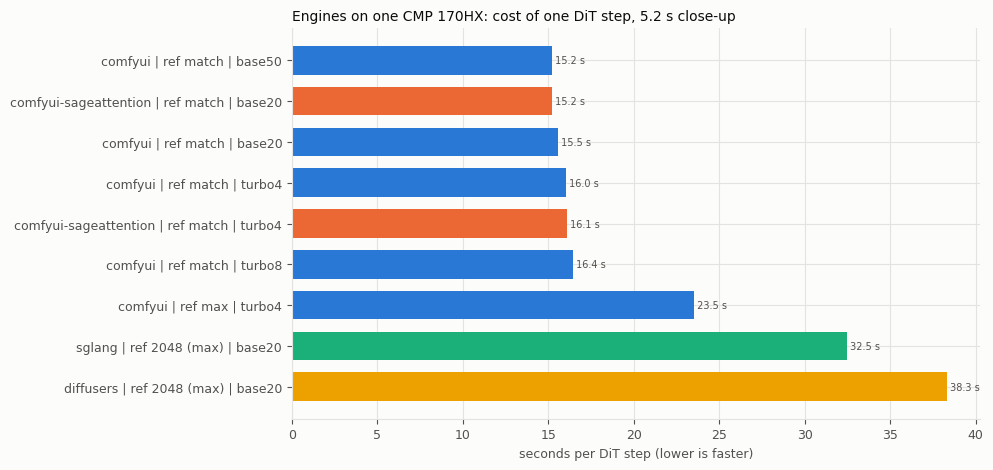

In [12]:
eng = ok[ok.task.isin(["T1_dialogue_closeup", "T3_voice_ref", "R1_public_closeup"]) & (ok.frames == 124) & (ok.width == 576) & (ok.power_cap_w == 140) & ~ok.tripped]
eng = eng.assign(label=eng.engine + " | ref " + eng.ref_size.fillna("-") + " | " + eng.config)
e = eng.groupby("label").agg(runs=("run_id", "count"), step_s=("step_s_mean", "mean"), wall_warm_s=("wall_s", lambda s: s[~eng.loc[s.index, "cold"]].mean()),
        load_s=("load_s", "max"), peak_vram_gib=("peak_vram_gib", "max"), wer=("wer", "mean")).reset_index().sort_values("step_s")
table(e, 2)
EC = {"comfyui": S[0], "comfyui-sageattention": S[1], "sglang": S[2], "diffusers": S[3]}
fig, ax = plt.subplots(figsize=(10, 0.42 * len(e) + 1))
bars = ax.barh(e.label, e.step_s, color=[EC[l.split(" | ")[0]] for l in e.label], height=0.7)
hbar_labels(ax, bars, "{:.1f} s"); ax.invert_yaxis(); ax.set_xlabel("seconds per DiT step (lower is faster)")
ax.set_title("Engines on one CMP 170HX: cost of one DiT step, 5.2 s close-up", loc="left")
plt.tight_layout(); plt.savefig(f"../assets/charts/{EXPERIMENT}-engines.png", dpi=130); plt.show()

### 2.7 Technical quality checks

Unprompted Whisper small.en on each clip's audio track, WER against the scripted line. These are technical checks, not creative approval: acting, identity and lip sync need human review. Script recall = share of scripted words present; inserted = extra words.

In [13]:
qa = ok[ok.wer.notna()].groupby(["task", "engine", "config"]).agg(runs=("run_id", "count"), exact_runs=("wer", lambda s: int((s == 0).sum())),
        mean_wer=("wer", "mean"), script_recall=("script_recall", "mean"), inserted_words=("inserted_words", "mean")).reset_index()
table(qa, 2)
nod = ok[ok.task.isin(["P1_kowloon_onetake", "P2_morning_rush", "P3_ugc_to_camera", "T5_t2va_broll"])][["run_id", "task", "config", "asr_text", "asr_vad_text", "audio_peak_dbfs"]]
display(Markdown("**No scripted line (community prompts, B-roll):** raw Whisper vs Whisper with VAD")); table(nod, 1)
print("clips with >= 1 full-scale audio sample:", int((ok.clipped_samples > 0).sum()), "of", int(ok.clipped_samples.notna().sum()))

| task                | engine                | config   |   runs |   exact_runs |   mean_wer |   script_recall |   inserted_words |
|:--------------------|:----------------------|:---------|-------:|-------------:|-----------:|----------------:|-----------------:|
| R1_public_closeup   | comfyui               | base20   |      2 |            2 |       0    |               1 |             0    |
| R1_public_closeup   | comfyui               | turbo4   |      6 |            5 |       0.02 |               1 |             0.17 |
| T1_dialogue_closeup | comfyui               | base20   |      3 |            3 |       0    |               1 |             0    |
| T1_dialogue_closeup | comfyui               | base50   |      1 |            1 |       0    |               1 |             0    |
| T1_dialogue_closeup | comfyui               | turbo4   |     27 |           23 |       0.01 |               1 |             0.15 |
| T1_dialogue_closeup | comfyui               | turbo8   |      1 |            1 |       0    |               1 |             0    |
| T1_dialogue_closeup | comfyui-sageattention | base20   |      1 |            1 |       0    |               1 |             0    |
| T1_dialogue_closeup | comfyui-sageattention | turbo4   |      2 |            2 |       0    |               1 |             0    |
| T1_dialogue_closeup | diffusers             | base20   |      1 |            1 |       0    |               1 |             0    |
| T1_dialogue_closeup | sglang                | base20   |      2 |            2 |       0    |               1 |             0    |
| T2_two_person       | comfyui               | base20   |      1 |            0 |       0.54 |               1 |             7    |
| T2_two_person       | comfyui               | turbo4   |      3 |            0 |       0.62 |               1 |             8    |
| T2_two_person       | comfyui               | turbo8   |      1 |            0 |       0.46 |               1 |             6    |
| T2_two_person       | comfyui-sageattention | turbo4   |      1 |            0 |       0.46 |               1 |             6    |
| T3_voice_ref        | comfyui               | base20   |      1 |            1 |       0    |               1 |             0    |
| T3_voice_ref        | comfyui               | turbo4   |      6 |            6 |       0    |               1 |             0    |
| T3_voice_ref        | comfyui               | turbo8   |      1 |            1 |       0    |               1 |             0    |
| T3_voice_ref        | comfyui-sageattention | turbo4   |      2 |            2 |       0    |               1 |             0    |
| T3_voice_ref        | sglang                | base20   |      1 |            1 |       0    |               1 |             0    |

**No scripted line (community prompts, B-roll):** raw Whisper vs Whisper with VAD

| run_id                           | task               | config   | asr_text                                                                                       | asr_vad_text                                                         |   audio_peak_dbfs |
|:---------------------------------|:-------------------|:---------|:-----------------------------------------------------------------------------------------------|:---------------------------------------------------------------------|------------------:|
| comm-cmp3-P1-turbo4-pl140-s10613 | P1_kowloon_onetake | turbo4   | thanks for watching                                                                            | hello ah i'll be back soon hello hello hello hello hello hello hello |              -2.7 |
| pwr-cmp3-P1-turbo4-pl200-s10619  | P1_kowloon_onetake | turbo4   | how are you i'm fine you're okay you're okay i'm fine i'm fine you're okay thank you thank you | oh                                                                   |              -2.3 |
| pwr-cmp3-P1-turbo4-pl250-s10620  | P1_kowloon_onetake | turbo4   | oh                                                                                             | what's going on                                                      |              -0   |
| comm-cmp3-P1-turbo8-pl140-s10616 | P1_kowloon_onetake | turbo8   | thank you thank you thank you                                                                  | oh                                                                   |              -0.2 |
| comm-cmp3-P2-turbo4-pl140-s10614 | P2_morning_rush    | turbo4   | thank you for watching                                                                         | thank you                                                            |              -2.3 |
| comm-cmp3-P2-turbo8-pl140-s10617 | P2_morning_rush    | turbo8   | thanks for watching                                                                            |                                                                      |              -5   |
| comm-cmp3-P3-turbo4-pl140-s10615 | P3_ugc_to_camera   | turbo4   | don't forget to like share and subscribe to our channel                                        | don't forget to like share and subscribe to our channel              |              -0.4 |
| comm-cmp3-P3-turbo8-pl140-s10618 | P3_ugc_to_camera   | turbo8   | thank you very much for watching and i'll see you next time                                    | thank you very much for watching and i'll see you next time          |              -2.7 |
| comfy-cmp2-T5-base20-s10501      | T5_t2va_broll      | base20   | thanks for watching                                                                            |                                                                      |              -1.3 |
| comfy-cmp2-T5-turbo4-s10501      | T5_t2va_broll      | turbo4   | thanks for watching                                                                            |                                                                      |               0   |
| comfy-cmp2-T5-turbo4-s10502      | T5_t2va_broll      | turbo4   | thanks for watching                                                                            | you                                                                  |              -6.5 |
| comfy-cmp2-T5-turbo8-s10501      | T5_t2va_broll      | turbo8   | thanks for watching                                                                            |                                                                      |               0   |
| comfy-cmp3-T5-turbo4-s10503      | T5_t2va_broll      | turbo4   | thanks for watching                                                                            |                                                                      |              -0   |

clips with >= 1 full-scale audio sample: 10 of 82


### 2.8 Throughput per card

Output video per card-hour at 140 W, first takes, Turbo 4-step. An episode here = 60 s of vertical drama from 12 shots: 8 close-ups (T1), 2 two-person shots (T2), 1 establishing shot (T4) and 1 insert (T5). The 200 W column scales the 140 W shot times by the measured 200 W ratio on the close-up (**inferred**).

| config   |   episode_min_one_card |   episode_min_three_cards |   episodes_per_hour_three_cards |   episode_min_one_card_200W_inferred |
|:---------|-----------------------:|--------------------------:|--------------------------------:|-------------------------------------:|
| turbo4   |                   19.2 |                       6.4 |                             9.4 |                                 14.2 |
| turbo8   |                   33.7 |                      11.2 |                             5.3 |                                 24.9 |
| base20   |                   75   |                      25   |                             2.4 |                                 55.4 |

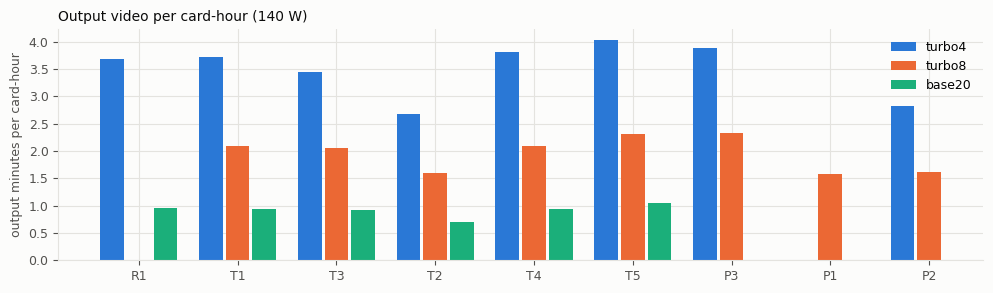

In [14]:
base = shots[shots.config.isin(["turbo4", "turbo8", "base20"])].groupby(["task", "config"]).agg(wall_s=("wall_s", "mean"), out_s=("out_s", "mean"),
        wh=("energy_wh", "mean")).reset_index()
base["out_min_per_card_hour"] = 3600 / base.wall_s * base.out_s / 60
mix = {"T1_dialogue_closeup": 8, "T2_two_person": 2, "T4_establishing_i2v": 1, "T5_t2va_broll": 1}
r200 = sweep[sweep.power_cap_w == 200].wall_s.mean() / sweep[sweep.power_cap_w == 140].wall_s.mean()
ep = []
for c in ["turbo4", "turbo8", "base20"]:
    b = base[base.config == c].set_index("task")
    if all(t in b.index for t in mix):
        s = sum(b.loc[t, "wall_s"] * n for t, n in mix.items())
        ep.append(dict(config=c, episode_min_one_card=s / 60, episode_min_three_cards=s / 180, episodes_per_hour_three_cards=3 * 3600 / s,
                       episode_min_one_card_200W_inferred=s * r200 / 60))
ep = pd.DataFrame(ep); table(ep, 1)
fig, ax = plt.subplots(figsize=(10, 3))
d = base.pivot(index="task", columns="config", values="out_min_per_card_hour").reindex([t for t in order if t in set(base.task)])
x = np.arange(len(d)); wd = 0.27
for i, c in enumerate([c for c in ["turbo4", "turbo8", "base20"] if c in d.columns]):
    b = ax.bar(x + i * wd, d[c], width=wd - 0.03, color=CFG[c], label=c)
ax.set_xticks(x + wd); ax.set_xticklabels([t.split("_")[0] for t in d.index]); ax.set_ylabel("output minutes per card-hour")
ax.set_title("Output video per card-hour (140 W)", loc="left"); ax.legend()
plt.tight_layout(); plt.savefig(f"../assets/charts/{EXPERIMENT}-throughput.png", dpi=130); plt.show()

### 2.9 Community prompts (most-liked original H3 prompts on X)

Three of the most-liked **original** MiniMax H3 prompts shared on X (collected via [videotoprompt.app](https://www.videotoprompt.app/trending-prompts/minimax), ranked by likes; posts that copy real people or franchise characters were skipped). Rendered unchanged, text only (T2VA on the FL2VA checkpoint), 576x1024, one card at 140 W.

| Task | Prompt authored by | Likes | Shot |
|---|---|---:|---|
| P1 | cocktail peanut ([@cocktailpeanut](https://x.com/cocktailpeanut/status/2084799914765341083)) | 388 | Kowloon Walled City one-take, 10.1 s |
| P2 | Noor ([@noorlewisx](https://x.com/noorlewisx/status/2088844629093601702)) | 324 | late-for-work morning rush, 10.1 s |
| P3 | Zara ([@ZaraIrahh](https://x.com/ZaraIrahh/status/2083011066800242986)) | 254 | talking-to-camera UGC, 5.2 s |

| run_id                           | card             |   power_cap_w | config   | cold   | tripped   |   out_s |   wall_s |   step_s_mean | asr_vad_text                                                         |
|:---------------------------------|:-----------------|--------------:|:---------|:-------|:----------|--------:|---------:|--------------:|:---------------------------------------------------------------------|
| comm-cmp3-P1-turbo4-pl140-s10613 | CMP-3            |           140 | turbo4   | True   | False     |    10.1 |    351   |          40.7 | hello ah i'll be back soon hello hello hello hello hello hello hello |
| pwr-cmp3-P1-turbo4-pl200-s10619  | CMP-3            |           200 | turbo4   | False  | False     |    10.1 |    152   |          31.2 | oh                                                                   |
| pwr-cmp3-P1-turbo4-pl250-s10620  | CMP-3            |           250 | turbo4   | False  | True      |    10.1 |    183.2 |          40   | what's going on                                                      |
| comm-cmp3-P1-turbo8-pl140-s10616 | CMP-3            |           140 | turbo8   | False  | False     |    10.1 |    384.9 |          42.5 | oh                                                                   |
| comm-cmp3-P2-turbo4-pl140-s10614 | CMP-3            |           140 | turbo4   | False  | False     |    10.1 |    215.5 |          41.5 | thank you                                                            |
| comm-cmp3-P2-turbo8-pl140-s10617 | CMP-3            |           140 | turbo8   | False  | False     |    10.1 |    377.8 |          42.3 |                                                                      |
| comm-cmp3-P3-turbo4-pl140-s10615 | CMP-3            |           140 | turbo4   | False  | False     |     5.2 |     79.8 |          14.2 | don't forget to like share and subscribe to our channel              |
| comm-cmp3-P3-turbo8-pl140-s10618 | CMP-3            |           140 | turbo8   | False  | False     |     5.2 |    133   |          14.4 | thank you very much for watching and i'll see you next time          |
| pub-cmp1-R1-base20-s10708        | CMP-1            |           140 | base20   | False  | False     |     5.2 |    322.8 |          15.2 | i kept every letter you sent i never opened them                     |
| pub-cmp1-R1-turbo4-pl140-s10701  | CMP-1            |           140 | turbo4   | False  | False     |     5.2 |     84.9 |          15.3 | i kept every letter you sent i never opened them                     |
| pub-cmp1-R1-turbo4-pl140-s10702  | CMP-1            |           140 | turbo4   | False  | False     |     5.2 |     81   |          15.7 | i kept every letter you sent i never opened them                     |
| pub-cmp2-R1-turbo4-pl140-s10703  | CMP-2            |           140 | turbo4   | False  | False     |     5.2 |     86.2 |          15.6 | i kept every letter you sent i never opened them                     |
| pub-cmp2-R1-turbo4-pl140-s10704  | CMP-2            |           140 | turbo4   | False  | False     |     5.2 |     84.7 |          16.4 | oh i kept every letter you sent i never opened them                  |
| pub-gb10-R1-base20-s10707        | DGX Spark (GB10) |           nan | base20   | False  | False     |     5.2 |    534   |          25   | i kept every letter you sent i never opened them                     |
| pub-gb10-R1-turbo4-pl140-s10705  | DGX Spark (GB10) |           nan | turbo4   | False  | False     |     5.2 |    149.4 |          26.7 | i kept every letter you sent i never opened them                     |
| pub-gb10-R1-turbo4-pl140-s10706  | DGX Spark (GB10) |           nan | turbo4   | False  | False     |     5.2 |    144   |          27.5 | i kept every letter you sent i never opened them                     |

`comfy-cmp2-T5-base20-s10501`

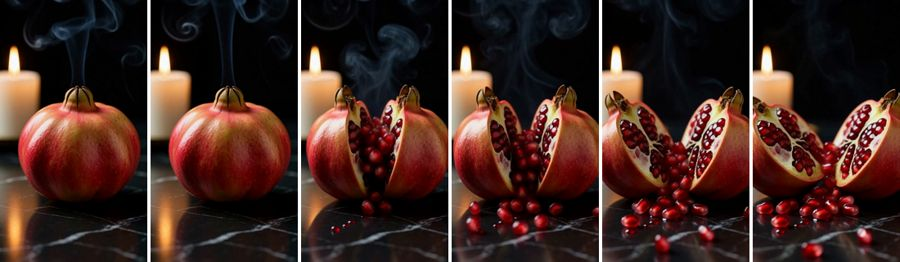

`comfy-cmp2-T5-turbo4-s10501`

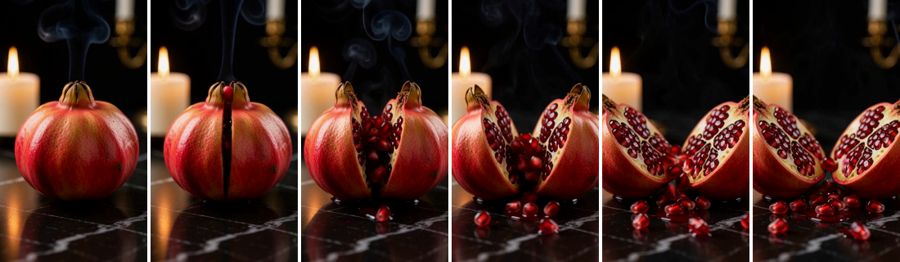

`comfy-cmp2-T5-turbo4-s10502`

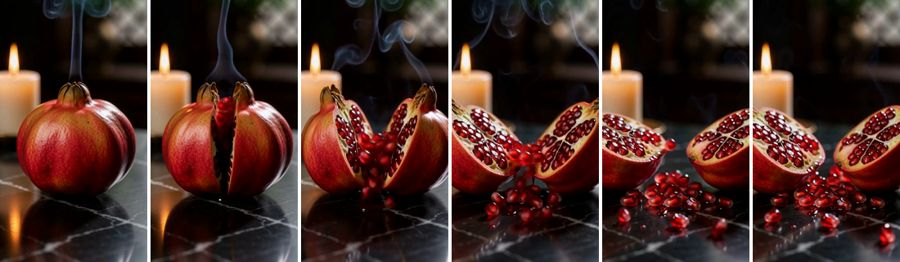

`comfy-cmp2-T5-turbo8-s10501`

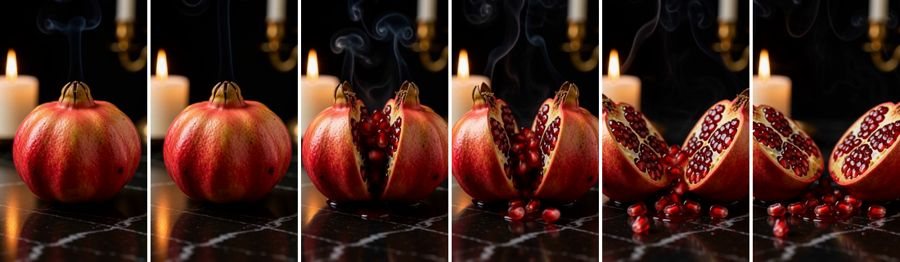

`comfy-cmp3-T5-turbo4-s10503`

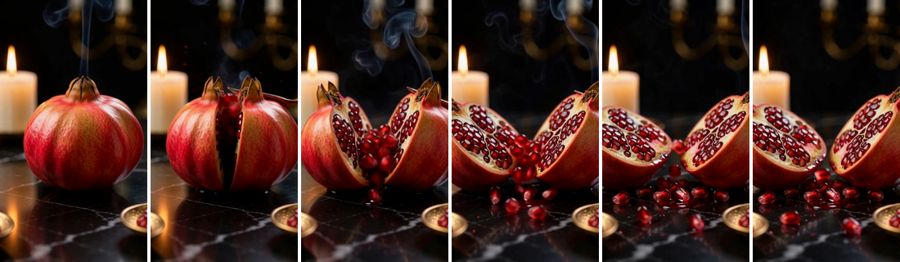

`comm-cmp3-P1-turbo4-pl140-s10613`

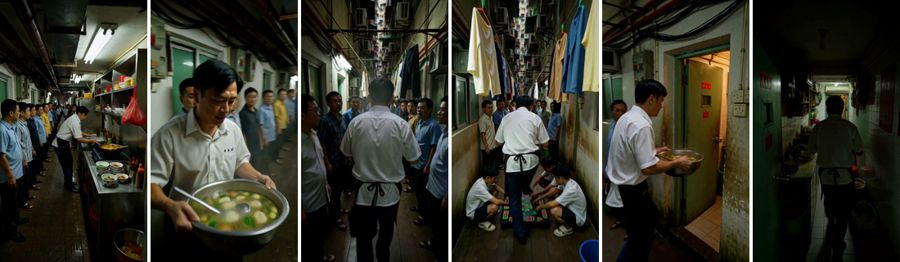

`comm-cmp3-P1-turbo8-pl140-s10616`

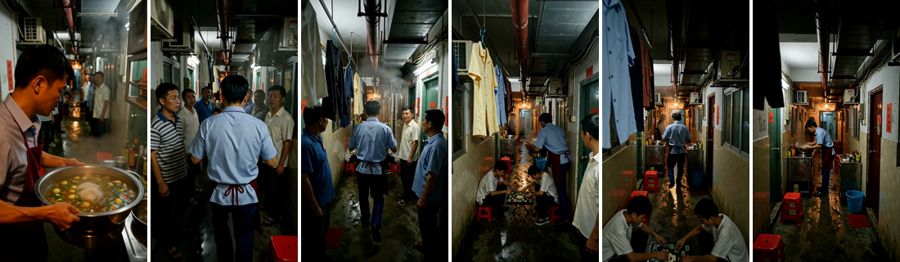

`comm-cmp3-P2-turbo4-pl140-s10614`

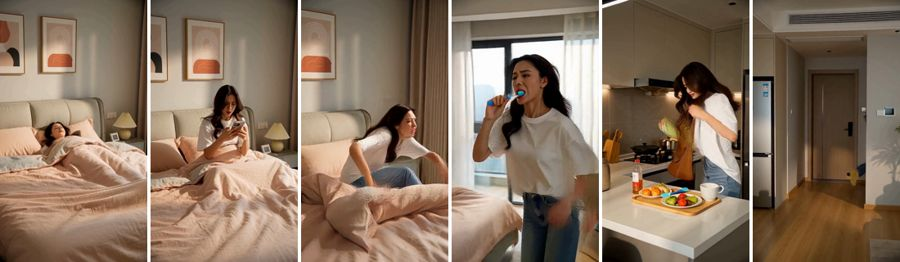

`comm-cmp3-P2-turbo8-pl140-s10617`

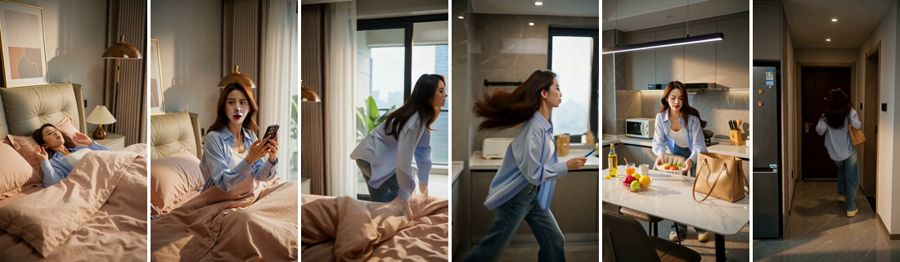

`comm-cmp3-P3-turbo4-pl140-s10615`

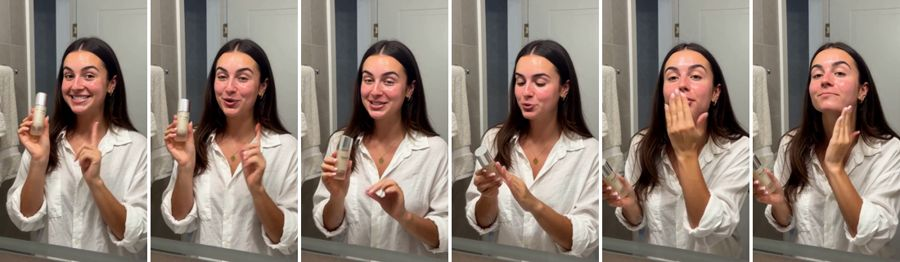

`comm-cmp3-P3-turbo8-pl140-s10618`

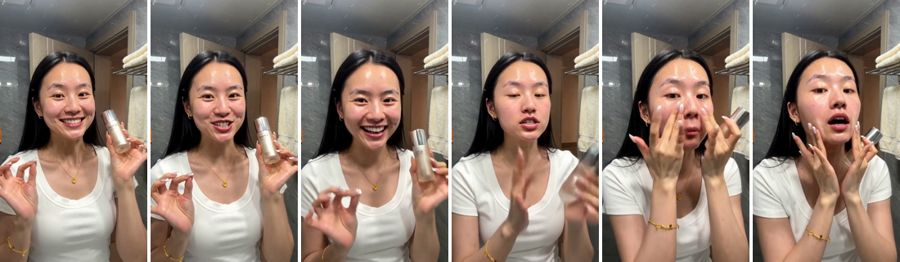

`pub-cmp1-R1-base20-s10708`

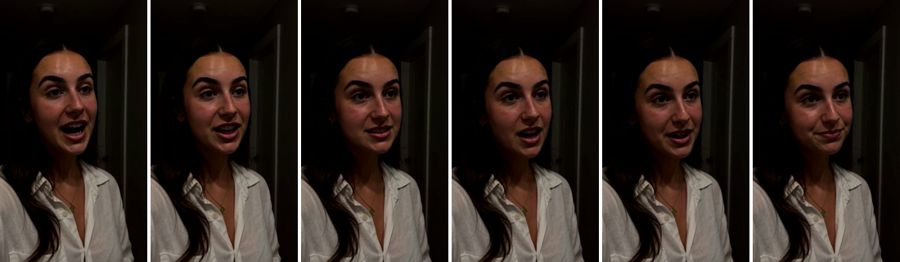

`pub-cmp1-R1-turbo4-pl140-s10701`

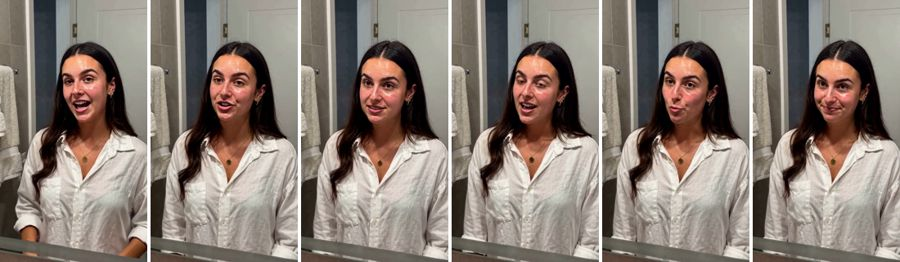

`pub-cmp1-R1-turbo4-pl140-s10702`

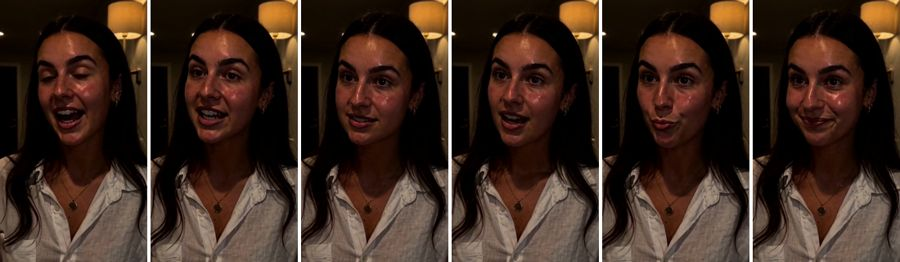

`pub-cmp2-R1-turbo4-pl140-s10703`

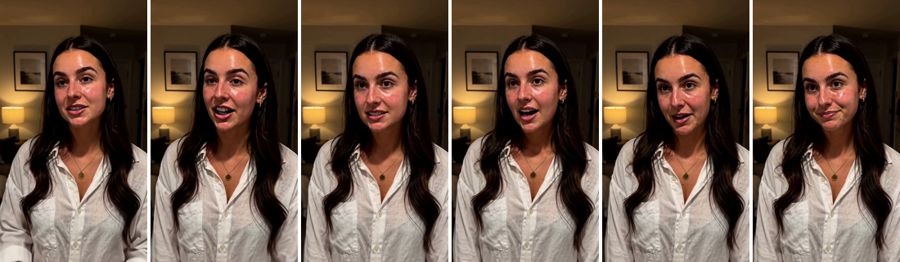

`pub-cmp2-R1-turbo4-pl140-s10704`

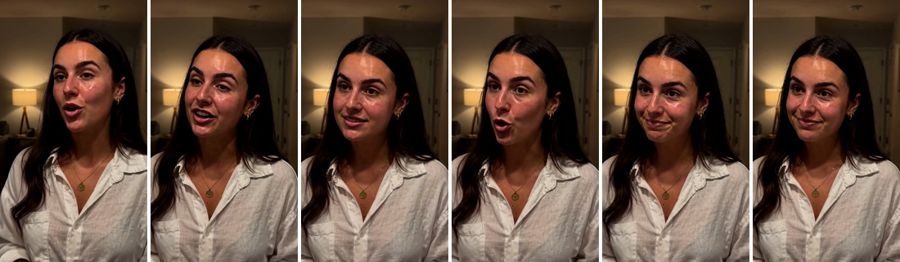

`pub-gb10-R1-base20-s10707`

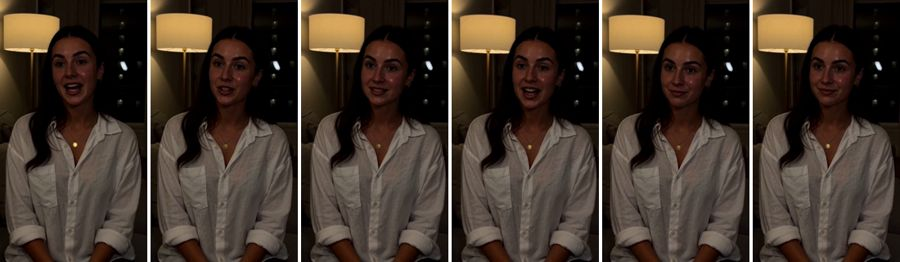

`pub-gb10-R1-turbo4-pl140-s10705`

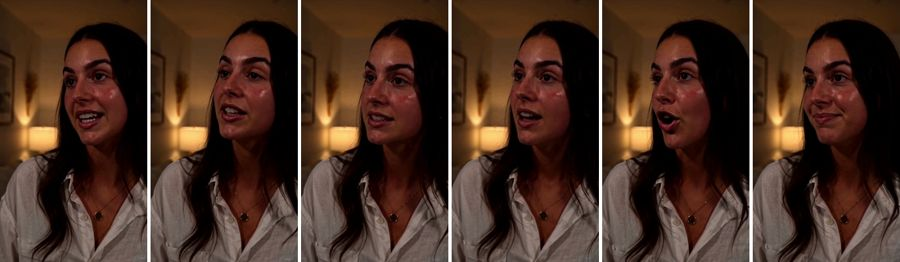

`pub-gb10-R1-turbo4-pl140-s10706`

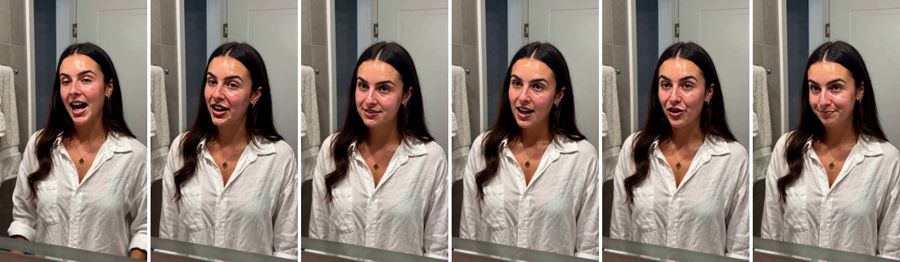

`pwr-cmp3-P1-turbo4-pl200-s10619`

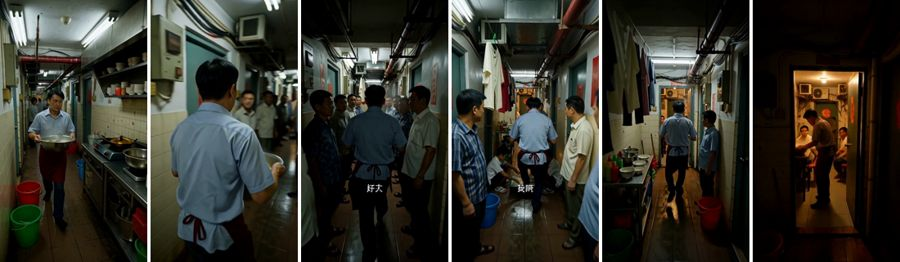

`pwr-cmp3-P1-turbo4-pl250-s10620`

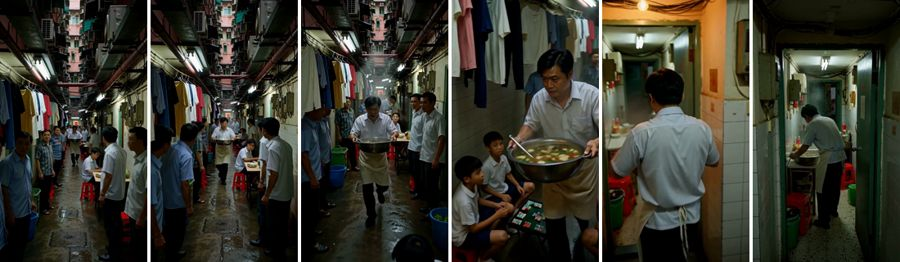

In [15]:
cp = ok[ok.task.str.startswith("P") | (ok.task == "R1_public_closeup")].sort_values(["task", "card", "config", "power_cap_w"])
table(cp[["run_id", "card", "power_cap_w", "config", "cold", "tripped", "out_s", "wall_s", "step_s_mean", "asr_vad_text"]], 1)
for f in sorted(os.listdir("../assets/images/minimax-h3-cmp170hx")):
    if f.endswith(".jpg"):
        display(Markdown(f"`{f[:-4]}`")); display(Image(filename=f"../assets/images/minimax-h3-cmp170hx/{f}", width=900))

## 3. Reproduce

**Hardware:** one CMP 170HX per engine process (64 GB HBM2e, sm80; unlocked with the pinned cmpunlocker build), PCIe Gen2 x16, forced airflow. Host RAM: ComfyUI needs ≤ 40 GiB per worker; diffusers needs 84 GiB to load. The model files need ~60 GB of disk (ComfyUI) or ~207 GB (official checkpoint for SGLang/diffusers).

**Card setup (host, as root):**

```bash
# driver: PixelML/cmpunlocker @ 6ca4da72f078553d37089ee741cd128aa7804504 (tag cmp170hx-plx-p2p-2026-10-02)
./install.sh --profile=8gb --no-gen2-service --no-iommu
# 170tune @ 5eb4775063b6cc055607ee5affecd210b13f0156 profiles used here: VBIOS 92.00.67 cards HBM NDIV 64; VBIOS 92.00.6D cards SM offset +200 at 1,410 MHz
nvidia-smi -pl 140          # every run unless the power-sweep table says otherwise
```

**Weights:**

```bash
hf download Comfy-Org/MiniMax-H3 --revision e5eb578a89295337b8ff433a035929ce0279e0b6 --local-dir models/h3 \
  diffusion_models/minimax_h3_ref2va_pruned_int8_convrot.safetensors diffusion_models/minimax_h3_fl2va_pruned_int8_convrot.safetensors \
  text_encoders/qwen3vl_32b_minimax_h3_int8_convrot.safetensors vae/minimax_h3_video_vae_fp16.safetensors vae/minimax_h3_audio_vae_fp32.safetensors
hf download larryvrh/MiniMax-H3-Turbo-Lora --revision 43a74557ac3f6539db8e0f2a959d03feb7a81480 --local-dir models/h3/loras \
  minimax_h3_turbo_v4_step600_ema.safetensors minimax_h3_turbo_4step_ema_ckpt850.safetensors
(cd models/h3 && sha256sum -c ../../results/2026-10-06-minimax-h3-video-1card-comfyui/receipts/env/SHA256SUMS)
# SGLang / diffusers also need the official checkpoint (~207 GB):
hf download MiniMaxAI/MiniMax-H3 --revision 42ed227ee7df40d41602854ae760620d6eb651fe --local-dir MiniMax-H3 \
  --include "Ref2VA/*" "transformer_ref/*" "vae/*" "audio_vae/*" "processor/*" "tokenizer/*" "scheduler/*" "audio_scheduler/*" "*.json"
rm -rf MiniMax-H3/text_encoder && ln -s Ref2VA/text_encoder MiniMax-H3/text_encoder   # same LFS blobs as text_encoder/; saves 62 GB
```

**ComfyUI (the measured setup):**

```bash
docker run --rm --gpus device=0 -p 8188:8188 -v $PWD/models/h3:/models:ro -v $PWD/app:/opt/app \
  pytorch/pytorch@sha256:bfbb4a2b4fdba0fefdb428ea737e626d61bb3daf74a16e1ff935bdb03aa7c3f0 bash -c \
  "python /opt/app/comfyui_setup.py && cd /opt/app/ComfyUI && /opt/app/venv/bin/python main.py --listen=0.0.0.0 --port=8188 \
   --extra-model-paths-config=/opt/app/extra_model_paths.yaml --highvram --disable-pinned-memory --preview-method=none"
# comfyui_setup.py (receipts/env/) fetches the pinned ComfyUI + node commits into /opt/app and builds the venv (lock: comfyui-venv-pip-freeze.txt)
# extra_model_paths.yaml: {library: {base_path: /models, diffusion_models: diffusion_models, text_encoders: text_encoders, vae: vae, loras: loras}}
# --gpu-only breaks VHS mp4 muxing (outputs stay on cuda); --disable-pinned-memory keeps host RAM in check
```

Then upload `receipts/inputs/r1-ref-p3-frame.png` (`POST /upload/image`) and submit any graph in `receipts/graphs/` (`POST /prompt`). The final cell below does this for R1. ComfyUI caches identical graphs: change `noise_seed` to re-measure.

**SGLang Diffusion (comparison):**

```bash
docker run --rm --gpus device=0 -p 30010:30010 -v $PWD/models:/models:ro -v $PWD/MiniMax-H3:/hf/MiniMax-H3:ro \
  lmsysorg/sglang@sha256:b1259f3ea3275f66237c498ea388919729018bc9f01c3d638391e06e2cf3f469 bash -c \
  "pip install comfy-kitchen==0.2.31 && sglang serve --model-path /hf/MiniMax-H3 --model-variant ref2va --num-gpus 1 --performance-mode speed \
   --component-weights-paths.transformer /models/h3/diffusion_models/minimax_h3_ref2va_pruned_int8_convrot.safetensors \
   --component-weights-paths.text_encoder /models/h3/text_encoders/qwen3vl_32b_minimax_h3_int8_convrot.safetensors \
   --enable-torch-compile false --disable-conditioning-cache --host 0.0.0.0 --port 30010"   # + --attention-backend torch_sdpa for the second run
# POST /v1/videos {task: ref2va, conditions: [{type: image, uri: file:///..., role: reference}], target: {short_edge: 576, aspect_ratio: "9:16", duration_seconds: 5.1667},
#                  num_inference_steps: 21, seed: 10501}   # 21 grid points = 20 model calls; the POST blocks until done on the first request
```

**diffusers (comparison):** `receipts/env/run_diffusers.py` with diffusers @ bc5e3bd9c55412cb74b6ac5e4c690fc7030461aa, torchao 0.18.0: torchao `Int8WeightOnlyConfig(version=2)` on `transformer_ref` (loaded to the GPU) and the Qwen3-VL text encoder (CPU), `ComponentsManager.enable_auto_cpu_offload`, `num_inference_steps=21`.

In [16]:
# --- Final editable request: R1 public close-up on ComfyUI (LIVE = False prints it only) ---
import copy, urllib.request
graph = json.load(open(f"{RECEIPTS}/graphs/pub-cmp1-R1-turbo4-pl140-s10701.json"))
graph = copy.deepcopy(graph)
graph["10"]["inputs"]["noise_seed"] = 10501        # any new seed; identical graphs are served from cache
graph["12"]["inputs"]["steps"] = 4                 # Turbo LoRA: 4-8 steps
print("prompt node:", graph["8"]["class_type"], graph["8"]["inputs"]["width"], "x", graph["8"]["inputs"]["height"], graph["8"]["inputs"]["length"], "frames")
if LIVE:
    base = os.environ[ENDPOINT_ENV_VAR].rstrip("/")
    img = f"{RECEIPTS}/inputs/r1-ref-p3-frame.png"
    boundary = "----h3bench"
    body = (f"--{boundary}\r\nContent-Disposition: form-data; name=\"image\"; filename=\"r1-ref-p3-frame.png\"\r\nContent-Type: image/png\r\n\r\n").encode() + open(img, "rb").read() + f"\r\n--{boundary}--\r\n".encode()
    urllib.request.urlopen(urllib.request.Request(base + "/upload/image", body, {"Content-Type": f"multipart/form-data; boundary={boundary}"}))
    r = urllib.request.urlopen(urllib.request.Request(base + "/prompt", json.dumps({"prompt": graph}).encode(), {"Content-Type": "application/json"}))
    print(json.load(r))

prompt node: MiniMaxH3ReferenceToVideo 576 x 1024 124 frames


## 4. Appendix

<details>
<summary>Failures, fixes, safety notes and limitations</summary>

**Failures kept as evidence**

- **OOM with two checkpoints in one ComfyUI worker.** The FL2VA DiT next to the Ref2VA DiT plus the text encoder (~72 GB) exceeds 64 GB; ComfyUI moves weights to host RAM until the 40 GiB pod limit kills the process (exit 137). Fix: one checkpoint per worker. The first FL2VA run after the swap is labelled `cold`.
- **SGLang first request.** `POST /v1/videos` blocks on the first request (more than 60 s), so a client timeout queued a second job behind it. Fix: client timeout 3,600 s; the two affected records are not in the receipts.
- **diffusers host RAM.** A 56 GiB pod limit was OOM-killed while transformers loaded the bf16 Qwen3-VL on CPU before quantizing; 84 GiB fits. The forward hooks did not separate encode and decode, so those land in "other" for that run.
- **Whisper on ambience.** Raw Whisper returns "thanks for watching" on clips without speech; the VAD pass returns nothing. WER is only computed where a line is scripted.
- **Card labels.** Recreating StatefulSet pods moved them to other cards; 18 run labels were corrected from the host's temperature log before publication.

**Safety deviation.** The repository's rule is to stop at 80 °C core. The power-sweep watchdog used 83 °C core / 85 °C HBM; the 200 W runs peaked at 79–81 °C and the tripped 250 W runs at 83–84 °C. All runs stayed below the card's 85 °C max operating temperature. Every card was returned to 140 W and the cap was verified with `nvidia-smi`.

**Not measured:** a sustained 200 W soak (30+ min); lip-sync scores; identity similarity; human acting review; multi-card (sequence-parallel) inference; the 768-px native resolution with the community prompts; SGLang/diffusers on the public inputs.

**Private tasks.** T1–T4 come from a private short-drama project: their prompts, reference images and voice references are withheld; only their timings and WER are published. R1 has the same geometry as T1 with public inputs, and its timings match T1 (85–86 s, 15.5 s/step).

**Credits.** Model: MiniMax (MiniMax-AI). Quantized ComfyUI files: Comfy-Org. Turbo LoRA and sampler: Larryvrh (@larryvrh). ComfyUI: comfyanonymous and Comfy Org. VideoHelperSuite: Kosinkadink. LTXVideo nodes: Lightricks. SGLang Diffusion: the SGLang team (sgl-project). diffusers and the H3 modular pipeline: Hugging Face, H3 integration PR #14355 authored by apolinario. torchao: PyTorch. SageAttention: thu-ml. faster-whisper: SYSTRAN. Whisper: OpenAI. jiwer: jitsi. Card tuning: cachenetics/170tune. Community prompts: cocktail peanut (@cocktailpeanut), Noor (@noorlewisx), Zara (@ZaraIrahh), collected via videotoprompt.app.

</details>